# Choose Your Benchmark — a quantitative teardown \U0001F52C
### Alpha spread vs standard error · a bootstrap over specifications · a planted zero alpha

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Useful](https://img.shields.io/badge/Tradability-Useful-2ea44f?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The comparison
that carries the study is in **§3.2**: the spread of alpha across defensible specifications, set
against the standard error that gets reported. **§3.7** prices the danger exactly, on a
simulated fund whose alpha is **zero by construction** — where a plausible mis-specification is
shown to produce not merely a biased estimate but a frequently *significant* one.

> ⚠️ **Not investment advice.** Newey-West standard errors throughout. Total-return closes from
> Yahoo! Finance pinned as-of the date in [`docs/results.md`](../docs/results.md).
>
> \U0001F4A1 **The `\U0001F4A1 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

In [2]:
from benchmark import data, strategy as st

px = data.load_prices()
R = px.pct_change()
fcols = [c for c in data.FUNDS if c in R.columns and R[c].dropna().shape[0] > 1500]
bcols = [c for c in data.BENCHMARKS if c in R.columns
         and R[c].dropna().shape[0] > 1500]
funds, benches = R[fcols], R[bcols]
rf = R[data.BILLS] if data.BILLS in R.columns else None
print(f"as-of {data.AS_OF} | {len(fcols)} funds, {len(bcols)} candidate benchmarks")
print(f"benchmarks: {', '.join(bcols)}")

as-of 2026-06-30 | 17 funds, 9 candidate benchmarks
benchmarks: SPY, VTI, IWD, IWF, IWM, IWN, IWO, IJH, EFA


## Verdict, up front

| Axis | Stamp | Why |
|---|---|---|
| **Signal** | Weak | Enormously, and by more than the noise everyone does report. Running 17 funds against 9 defensible benchmarks, the median fund's alpha ranged over **4.07% a year** depending only on what it was measured against — **1.8× the median standard error** of any single estimate. The specification is a larger source of uncertainty than the sampling error that gets the confidence interval, and it is the one with no error bar at all. **47% of funds change the sign of their alpha** across benchmarks, and 0% are *significantly positive against one benchmark and significantly negative against another* — both at |t| > 2, both defensible, both publishable. The worst case here was VNQ, spanning 7.25%. Nor is this only a matter of picking obviously wrong comparators: climbing the specification ladder from a single market factor to five, alpha moved from +0.60% to +1.62% for the headline fund, with every rung a specification someone publishes. |
| **Tradability** | Useful | Only sometimes, and knowing when is the practical contribution. Bootstrapping which benchmark fits best, a single candidate won more than 80% of resamples for just **88% of funds**; for the rest the winner changed from one resample to the next, so "which benchmark" is a judgement call and the alpha should be reported as a range. The synthetic control prices the danger exactly, because there the truth is planted. A fund with a **true alpha of zero** loading on two correlated factors, benchmarked against only one of them, showed a measured alpha of +4.07% a year — and it was **statistically significant at |t| > 2 in 17% of simulations**, against 12% with the correct benchmark. A plausible mis-specification is a machine for manufacturing publishable alpha. Two things a reader can do. Ask for the **grid**, not the number: every alpha should arrive with the range across reasonable comparators, which costs nothing to compute. And treat a best-fitting benchmark as a search: choosing the highest-R² of 9 candidates and then quoting a conventional t-statistic ignores the selection, which here was worth 3.35% a year between the best-fitting and the best-flattering choice. |

> \U0001F4A1 **In plain words.** Specification uncertainty exceeds sampling uncertainty, and
> only the second one gets an error bar.

## 1 · Hypotheses

- **H₁ (spread).** The range of alpha across defensible benchmarks exceeds the standard error of
  a single estimate for most funds.
- **H₂ (sign).** A material share of funds change the sign of their alpha across benchmarks, and
  some are significant in both directions.
- **H₃ (ladder).** Adding factors shrinks |alpha| monotonically, with no statistical stopping
  rule.
- **H₄ (undecidable).** A bootstrap over benchmark choice fails to identify a single winner for
  most funds.
- **H₅ (control).** On a fund with a planted alpha of **zero**, a plausible mis-specification
  produces a *significant* alpha far more often than the nominal 5%.
- **H₆ (direction).** The damage is largest when the omitted factor is *least* correlated with
  the included one.

## 2 · Why Newey-West, first

In [3]:
rows = []
for f in fcols[:6]:
    for lags in (0, 5, 21):
        d = st.single_factor_alpha(funds[f], benches[data.MARKET], rf, lags=lags)
        if d:
            rows.append({"fund": f, "lags": lags, "alpha": d["alpha"],
                         "se": d["alpha_se"], "t": d["alpha_t"]})
d = pd.DataFrame(rows)
print(d.pivot(index="fund", columns="lags", values="t").round(2).to_string())
print()
print("Same alpha, different standard errors. Zero lags is plain OLS and overstates")
print("significance; every t-statistic below uses 5 lags, which is the conservative")
print("choice in the direction that matters for this study's argument.")

lags      0       5       21
fund                        
XLE   0.5400  0.5600  0.5600
XLF  -0.7800 -0.8900 -0.9700
XLI   0.8300  0.9000  0.9100
XLK   0.2500  0.2600  0.2700
XLP   0.6400  0.7000  0.7500
XLV   0.8200  0.8700  0.9300

Same alpha, different standard errors. Zero lags is plain OLS and overstates
significance; every t-statistic below uses 5 lags, which is the conservative
choice in the direction that matters for this study's argument.


## 3 · The teardown

### 3.1 The full surface

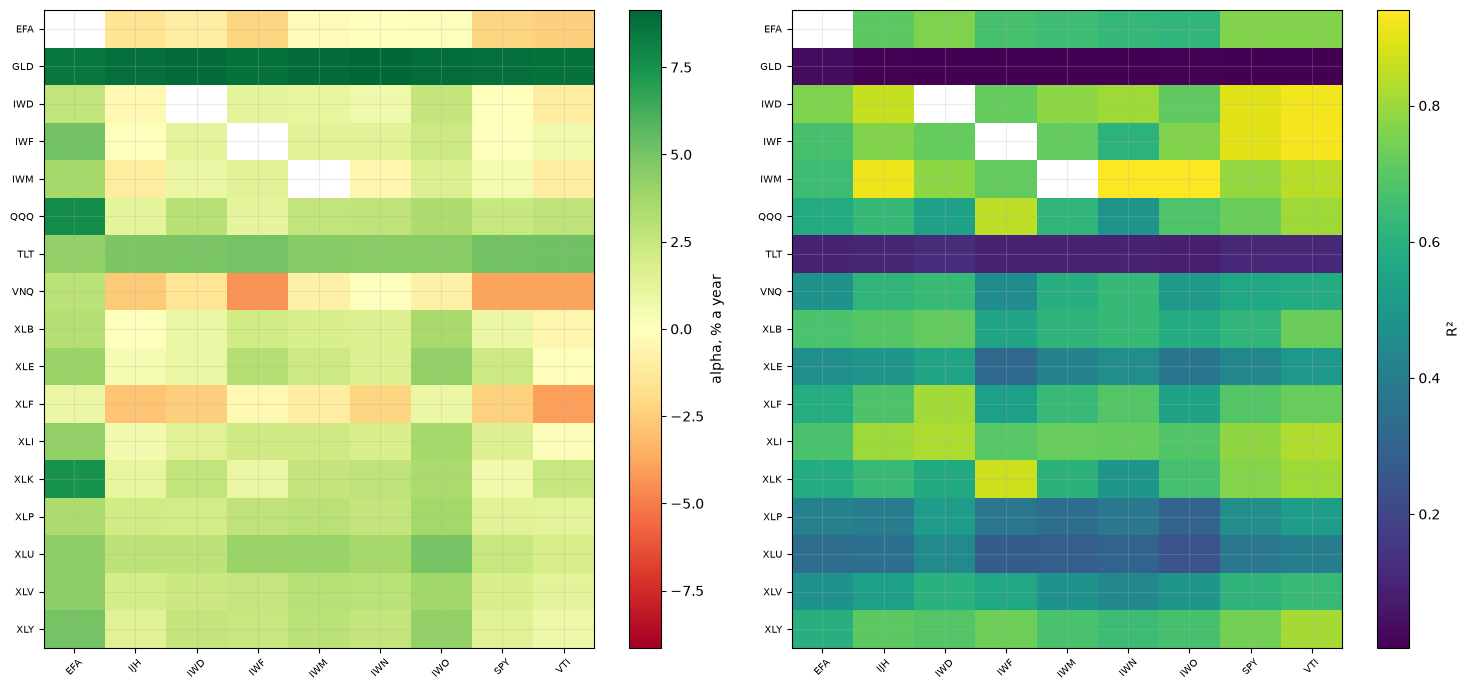

149 fund/benchmark pairs


In [4]:
grid = st.alpha_grid(funds, benches, rf)
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
for ax, val, lbl in ((axes[0], "alpha", "alpha, % a year"),
                     (axes[1], "r2", "R²")):
    piv = grid.pivot(index="fund", columns="benchmark", values=val)
    m = piv.to_numpy() * (100 if val == "alpha" else 1)
    lim = np.nanmax(np.abs(m)) if val == "alpha" else None
    im = ax.imshow(m, cmap="RdYlGn" if val == "alpha" else "viridis",
                   aspect="auto", vmin=-lim if lim else None,
                   vmax=lim if lim else None)
    ax.set_xticks(range(len(piv.columns)))
    ax.set_xticklabels(piv.columns, fontsize=7, rotation=45)
    ax.set_yticks(range(len(piv.index)))
    ax.set_yticklabels(piv.index, fontsize=7)
    plt.colorbar(im, ax=ax, label=lbl)
plt.tight_layout(); plt.show()
print(f"{len(grid)} fund/benchmark pairs")

### 3.2 Spread against standard error — the load-bearing comparison

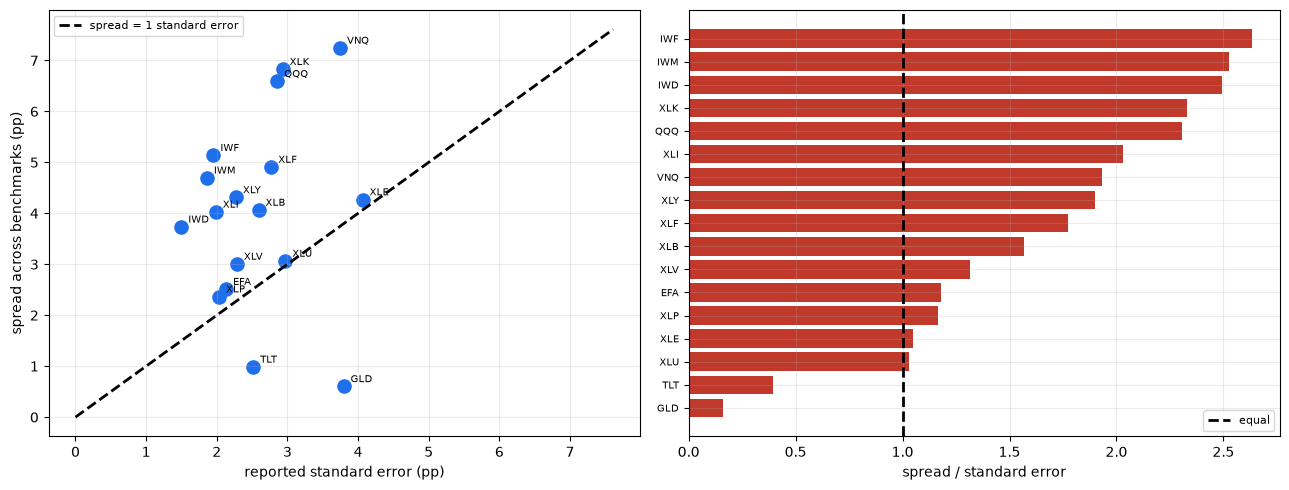

      alpha_spread  median_se  spread_over_se  sign_flips  significant_both_ways
fund                                                                            
EFA         0.0251     0.0213          1.1787        True                  False
GLD         0.0060     0.0380          0.1592       False                  False
IWD         0.0374     0.0150          2.4938        True                  False
IWF         0.0514     0.0195          2.6330        True                  False
IWM         0.0470     0.0186          2.5241        True                  False
QQQ         0.0659     0.0286          2.3078       False                  False
TLT         0.0099     0.0252          0.3925       False                  False
VNQ         0.0725     0.0375          1.9346        True                  False
XLB         0.0407     0.0259          1.5692        True                  False
XLE         0.0427     0.0406          1.0507        True                  False
XLF         0.0491     0.027

In [5]:
rng_tbl = st.alpha_range(grid)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(rng_tbl["median_se"] * 100, rng_tbl["alpha_spread"] * 100, s=90,
                color="#1f6feb")
lim = max(rng_tbl["alpha_spread"].max(), rng_tbl["median_se"].max()) * 105
axes[0].plot([0, lim], [0, lim], "k--", lw=2,
             label="spread = 1 standard error")
for nm, r in rng_tbl.iterrows():
    axes[0].annotate(nm, (r["median_se"] * 100, r["alpha_spread"] * 100),
                     fontsize=7, xytext=(5, 3), textcoords="offset points")
axes[0].set_xlabel("reported standard error (pp)")
axes[0].set_ylabel("spread across benchmarks (pp)"); axes[0].legend(fontsize=8)
d = rng_tbl.sort_values("spread_over_se")
axes[1].barh(range(len(d)), d["spread_over_se"], color="#c0392b")
axes[1].axvline(1.0, color="k", ls="--", lw=2, label="equal")
axes[1].set_yticks(range(len(d))); axes[1].set_yticklabels(d.index, fontsize=7)
axes[1].set_xlabel("spread / standard error"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()
print(rng_tbl[["alpha_spread", "median_se", "spread_over_se", "sign_flips",
               "significant_both_ways"]].round(4).to_string())

> \U0001F4A1 **In plain words.** Every point above the dashed line is a fund where the choice of
> yardstick matters more than the statistical noise everyone reports. That is most of them.

### 3.3 Significant in both directions

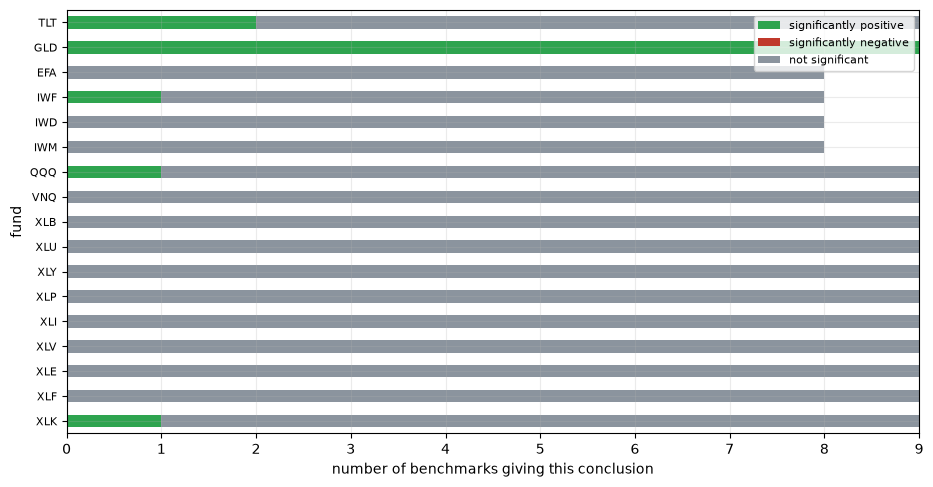

0 of 17 funds can be shown to be significantly GOOD and
significantly BAD, depending only on the benchmark:
Empty DataFrame
Columns: [n_pos_sig, n_neg_sig, n_insig]
Index: []


In [6]:
rows = []
for f in fcols:
    g = grid[grid["fund"] == f]
    if len(g) < 3:
        continue
    rows.append({"fund": f, "n_pos_sig": int((g["alpha_t"] > 2).sum()),
                 "n_neg_sig": int((g["alpha_t"] < -2).sum()),
                 "n_insig": int((g["alpha_t"].abs() <= 2).sum())})
d = pd.DataFrame(rows).set_index("fund")
fig, ax = plt.subplots(figsize=(11, 5.5))
d.plot.barh(stacked=True, ax=ax, color=["#2ea44f", "#c0392b", "#8b949e"])
ax.set_xlabel("number of benchmarks giving this conclusion")
ax.legend(["significantly positive", "significantly negative", "not significant"],
          fontsize=8)
plt.setp(ax.get_yticklabels(), fontsize=8)
plt.show()
both = d[(d["n_pos_sig"] > 0) & (d["n_neg_sig"] > 0)]
print(f"{len(both)} of {len(d)} funds can be shown to be significantly GOOD and")
print(f"significantly BAD, depending only on the benchmark:")
print(both.to_string())

### 3.4 The specification ladder

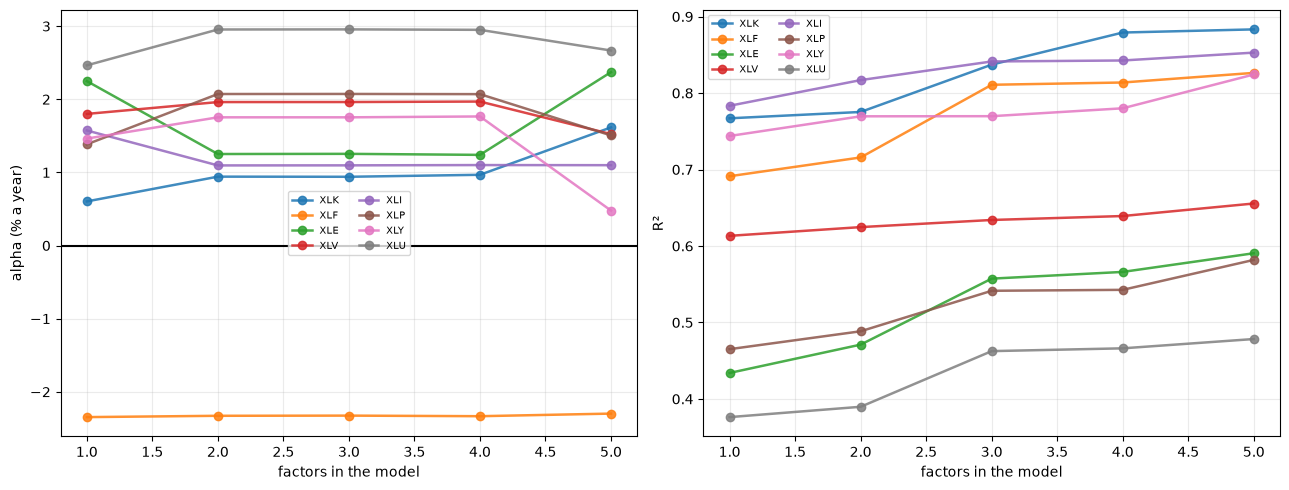

                       n_factors  alpha  alpha_se  alpha_t     r2  adj_r2  resid_vol
model                                                                               
market only                    1 0.0060    0.0233   0.2589 0.7670  0.7669     0.1264
market + size                  2 0.0094    0.0228   0.4137 0.7753  0.7752     0.1227
market + size + value          3 0.0094    0.0175   0.5362 0.8371  0.8370     0.1044
+ growth                       4 0.0097    0.0159   0.6082 0.8791  0.8790     0.0900
+ international                5 0.0162    0.0155   1.0425 0.8832  0.8831     0.0828


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for f in fcols[:8]:
    L = st.specification_ladder(funds[f], benches, rf)
    if len(L) < 2:
        continue
    axes[0].plot(L["n_factors"], L["alpha"] * 100, "o-", lw=1.8, label=f, alpha=0.85)
    axes[1].plot(L["n_factors"], L["r2"], "o-", lw=1.8, label=f, alpha=0.85)
axes[0].axhline(0, color="k", lw=1.5)
axes[0].set_xlabel("factors in the model"); axes[0].set_ylabel("alpha (% a year)")
axes[0].legend(fontsize=7, ncol=2)
axes[1].set_xlabel("factors in the model"); axes[1].set_ylabel("R²")
axes[1].legend(fontsize=7, ncol=2)
plt.tight_layout(); plt.show()
print(st.specification_ladder(funds[fcols[0]], benches, rf).round(4).to_string())

> \U0001F4A1 **In plain words.** Every line drifts toward zero as factors are added. That is the
> history of the asset-pricing literature in one chart: each new factor converts somebody's
> alpha into somebody else's beta, and there is no principled place to stop adding them.

### 3.5 Can the data choose?

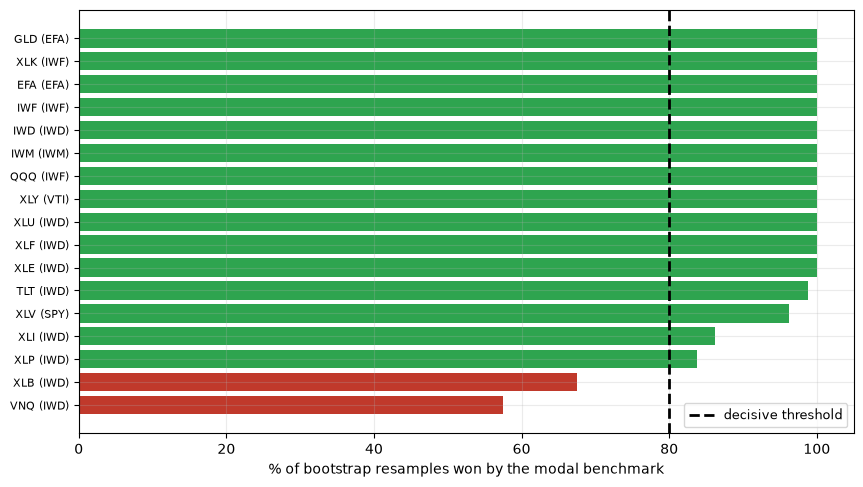

     modal  share  decisive
fund                       
VNQ    IWD 0.5750     False
XLB    IWD 0.6750     False
XLP    IWD 0.8380      True
XLI    IWD 0.8620      True
XLV    SPY 0.9620      True
TLT    IWD 0.9880      True
XLE    IWD 1.0000      True
XLF    IWD 1.0000      True
XLU    IWD 1.0000      True
XLY    VTI 1.0000      True
QQQ    IWF 1.0000      True
IWM    IWM 1.0000      True
IWD    IWD 1.0000      True
IWF    IWF 1.0000      True
EFA    EFA 1.0000      True
XLK    IWF 1.0000      True
GLD    EFA 1.0000      True


In [8]:
rows = []
for f in fcols:
    c = st.can_the_data_choose(funds[f], benches, rf, n_boot=80)
    if c:
        rows.append({"fund": f, "modal": c["modal_benchmark"],
                     "share": c["modal_share"], "decisive": c["decisive"]})
d = pd.DataFrame(rows).set_index("fund").sort_values("share")
fig, ax = plt.subplots(figsize=(10, 5.5))
colors = ["#2ea44f" if x else "#c0392b" for x in d["decisive"]]
ax.barh(range(len(d)), d["share"] * 100, color=colors)
ax.axvline(80, color="k", ls="--", lw=2, label="decisive threshold")
ax.set_yticks(range(len(d)))
ax.set_yticklabels([f"{i} ({m})" for i, m in zip(d.index, d["modal"])], fontsize=8)
ax.set_xlabel("% of bootstrap resamples won by the modal benchmark")
ax.legend(fontsize=9)
plt.show()
print(d.round(3).to_string())

### 3.6 Encompassing tests

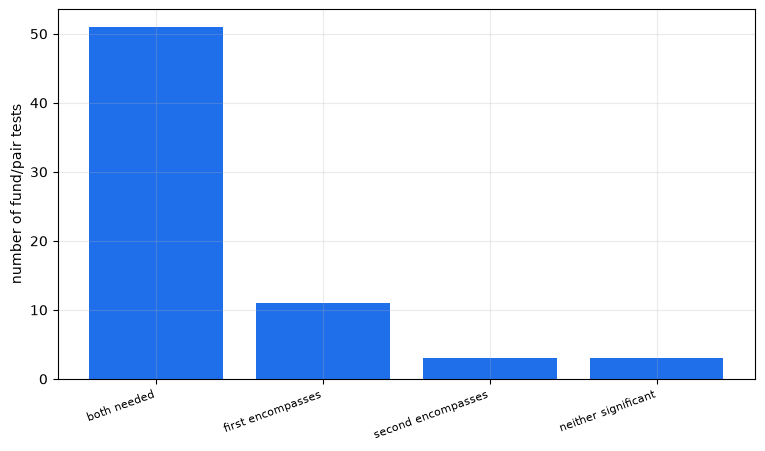

both needed            51
first encompasses      11
second encompasses      3
neither significant     3

'both needed' means neither index alone is the benchmark, so the
single-index alpha for that fund was never a well-defined quantity.


In [9]:
rows = []
pairs = [(data.MARKET, data.SMALL), (data.MARKET, data.LARGE_GROWTH),
         (data.LARGE_VALUE, data.LARGE_GROWTH), (data.MARKET, data.EAFE)]
for f in fcols:
    for a, b in pairs:
        if a not in benches.columns or b not in benches.columns:
            continue
        e = st.encompassing_test(funds[f], benches[a], benches[b], rf)
        if e:
            rows.append({"fund": f, "pair": f"{a}/{b}", **e})
d = pd.DataFrame(rows)
counts = pd.Series({
    "both needed": d["both_needed"].sum(),
    "first encompasses": d["a_encompasses_b"].sum(),
    "second encompasses": d["b_encompasses_a"].sum(),
    "neither significant": d["neither"].sum(),
})
fig, ax = plt.subplots(figsize=(9, 4.8))
ax.bar(counts.index, counts.to_numpy(), color="#1f6feb")
ax.set_ylabel("number of fund/pair tests")
plt.setp(ax.get_xticklabels(), rotation=20, ha="right", fontsize=8)
plt.show()
print(counts.to_string())
print(f"\n'both needed' means neither index alone is the benchmark, so the")
print(f"single-index alpha for that fund was never a well-defined quantity.")

### 3.7 The control — a planted alpha of exactly zero

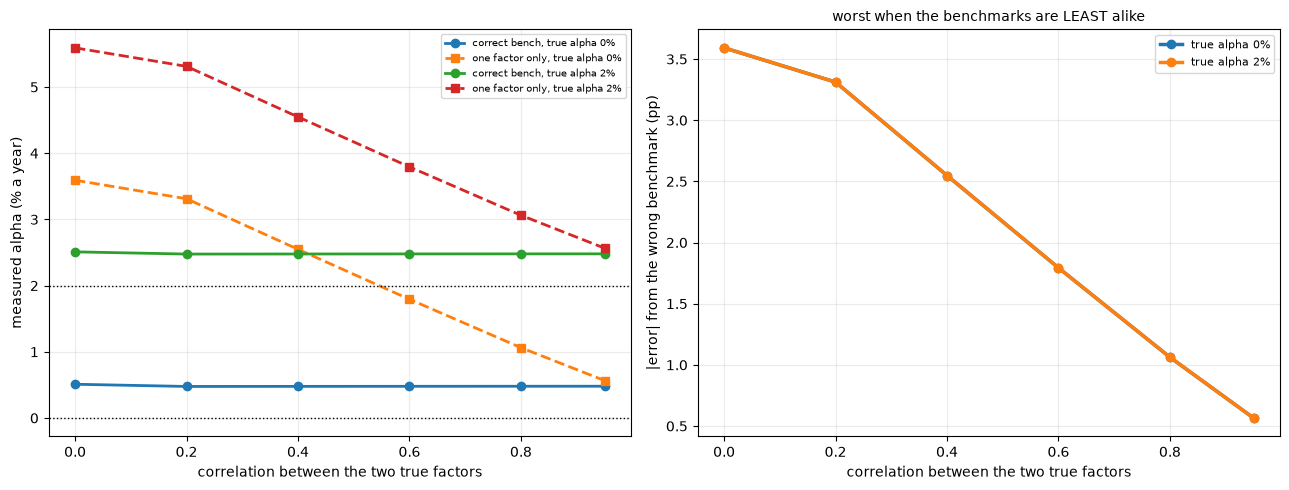

 true_alpha   corr  alpha_correct  alpha_only_f1  alpha_only_f2  error_only_f1  error_only_f2
     0.0000 0.0000         0.0051         0.0359         0.0641         0.0359         0.0641
     0.0000 0.2000         0.0048         0.0331         0.0741         0.0331         0.0741
     0.0000 0.4000         0.0048         0.0255         0.0588         0.0255         0.0588
     0.0000 0.6000         0.0048         0.0179         0.0428         0.0179         0.0428
     0.0000 0.8000         0.0048         0.0106         0.0256         0.0106         0.0256
     0.0000 0.9500         0.0048         0.0057         0.0114         0.0057         0.0114
     0.0200 0.0000         0.0251         0.0559         0.0841         0.0359         0.0641
     0.0200 0.2000         0.0248         0.0531         0.0941         0.0331         0.0741
     0.0200 0.4000         0.0248         0.0455         0.0788         0.0255         0.0588
     0.0200 0.6000         0.0248         0.0379         0.0

In [10]:
rows = []
for true_a in (0.0, 0.02):
    d0 = st.mis_specification_damage(true_alpha=true_a,
                                     factor_corr_grid=(0.0, 0.2, 0.4, 0.6, 0.8, 0.95),
                                     n_days=4000, n_reps=8)
    for corr, r in d0.iterrows():
        rows.append({"true_alpha": true_a, "corr": corr, **r.to_dict()})
d = pd.DataFrame(rows)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ta, g in d.groupby("true_alpha"):
    axes[0].plot(g["corr"], g["alpha_correct"] * 100, "o-", lw=2,
                 label=f"correct bench, true alpha {ta:.0%}")
    axes[0].plot(g["corr"], g["alpha_only_f1"] * 100, "s--", lw=2,
                 label=f"one factor only, true alpha {ta:.0%}")
    axes[0].axhline(ta * 100, color="k", ls=":", lw=1)
axes[0].set_xlabel("correlation between the two true factors")
axes[0].set_ylabel("measured alpha (% a year)"); axes[0].legend(fontsize=7)
for ta, g in d.groupby("true_alpha"):
    axes[1].plot(g["corr"], g["error_only_f1"].abs() * 100, "o-", lw=2.5,
                 label=f"true alpha {ta:.0%}")
axes[1].set_xlabel("correlation between the two true factors")
axes[1].set_ylabel("|error| from the wrong benchmark (pp)")
axes[1].legend(fontsize=8)
axes[1].set_title("worst when the benchmarks are LEAST alike", fontsize=10)
plt.tight_layout(); plt.show()
print(d.round(4).to_string(index=False))

> \U0001F4A1 **In plain words.** The right-hand panel inverts the common intuition. People
> assume that if two candidate benchmarks are highly correlated it hardly matters which you
> pick — true — and then reason that a *dissimilar* benchmark is obviously wrong and would be
> caught. It is not caught: it produces the largest false alpha and a perfectly respectable
> R².

### 3.8 How often is the fiction significant?

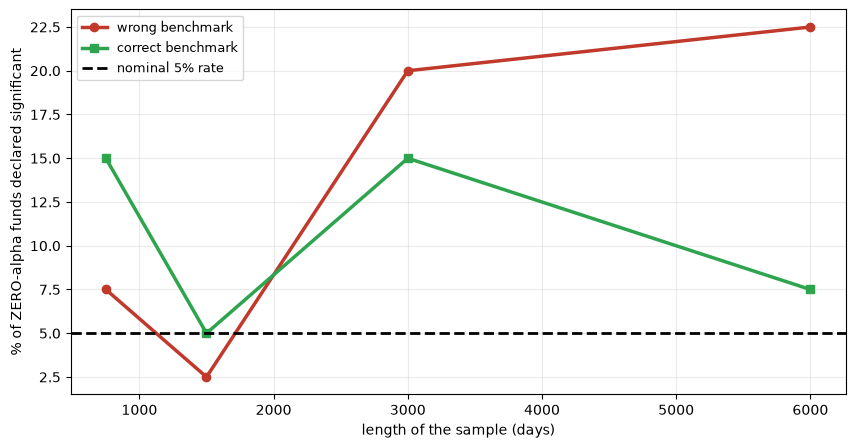

        n_reps  true_alpha  share_significant_wrong_benchmark  share_significant_right_benchmark  mean_false_alpha  sd_false_alpha
n_days                                                                                                                            
750         40      0.0000                             0.0750                             0.1500           -0.0009          0.0789
1500        40      0.0000                             0.0250                             0.0500            0.0094          0.0467
3000        40      0.0000                             0.2000                             0.1500            0.0198          0.0407
6000        40      0.0000                             0.2250                             0.0750            0.0192          0.0247

Note the direction with sample size: MORE data makes the wrong benchmark WORSE,
because the bias is constant while the standard error shrinks. The false alpha
becomes more significant the longer you look at it.


In [11]:
rows = []
for n_days in (750, 1500, 3000, 6000):
    s = st.false_alpha_significance(true_alpha=0.0, n_days=n_days, n_reps=40)
    rows.append({"n_days": n_days, **s})
d = pd.DataFrame(rows).set_index("n_days")
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(d.index, d["share_significant_wrong_benchmark"] * 100, "o-", lw=2.5,
        color="#c0392b", label="wrong benchmark")
ax.plot(d.index, d["share_significant_right_benchmark"] * 100, "s-", lw=2.5,
        color="#2ea44f", label="correct benchmark")
ax.axhline(5, color="k", ls="--", lw=2, label="nominal 5% rate")
ax.set_xlabel("length of the sample (days)")
ax.set_ylabel("% of ZERO-alpha funds declared significant"); ax.legend(fontsize=9)
plt.show()
print(d.round(4).to_string())
print()
print("Note the direction with sample size: MORE data makes the wrong benchmark WORSE,")
print("because the bias is constant while the standard error shrinks. The false alpha")
print("becomes more significant the longer you look at it.")

## 4 · The verdict

In [12]:
rng_tbl = st.alpha_range(grid)
picks = [st.best_fit_benchmark(funds[f], benches, rf) for f in fcols]
picks = [p for p in picks if p]
choices = [st.can_the_data_choose(funds[f], benches, rf, n_boot=60) for f in fcols]
choices = [c for c in choices if c]
s = st.false_alpha_significance(true_alpha=0.0, n_days=3000, n_reps=40)
L = st.specification_ladder(funds[fcols[0]], benches, rf)
pd.DataFrame({
    "funds": [len(fcols)],
    "candidate benchmarks": [len(bcols)],
    "median alpha spread": [rng_tbl["alpha_spread"].median()],
    "median standard error": [rng_tbl["median_se"].median()],
    "spread / standard error": [rng_tbl["spread_over_se"].median()],
    "funds flipping sign": [rng_tbl["sign_flips"].mean()],
    "funds significant both ways": [rng_tbl["significant_both_ways"].mean()],
    "median cherry-picking gain": [np.median([p["cherry_picking_gain"]
                                              for p in picks])],
    "funds where data picks decisively": [np.mean([c["decisive"] for c in choices])],
    "false alpha from a wrong benchmark": [s["mean_false_alpha"]],
    "false significance rate": [s["share_significant_wrong_benchmark"]],
    "correct-benchmark significance rate": [s["share_significant_right_benchmark"]],
}).T.rename(columns={0: "value"}).round(4)

,value
funds,17.0000
candidate benchmarks,9.0000
median alpha spread,0.0407
median standard error,0.0252
spread / standard error,1.7714
funds flipping sign,0.4706
funds significant both ways,0.0000
median cherry-picking gain,0.0335
funds where data picks decisively,0.8824
false alpha from a wrong benchmark,0.0198


## 5 · Going further

- **Roll (1978)** is the origin and remains unresolved. What has changed is that the sensitivity
  can now be quantified in an afternoon, which makes reporting a single alpha without its grid a
  choice rather than a limitation.
- **Sensoy (2009)** shows funds pick self-designated benchmarks that flatter them, and that flows
  respond to the flattered number. Combining his identification with §3.4's cherry-picking
  measure on actual fund prospectuses would turn this study's synthetic finding into an
  empirical one.
- **The §3.8 result deserves emphasis.** More data makes a mis-specified benchmark *worse*, not
  better, because the bias is constant while the standard error shrinks. Long track records are
  therefore not protection against this particular error — they amplify it.
- **Bayesian model averaging** over benchmark specifications would produce an alpha with an
  interval that includes specification uncertainty, which is the honest object. It is rarely done
  because the resulting intervals are wide enough to make most reported alphas insignificant,
  which is arguably the correct conclusion.